In [1]:
# !pip install -q matplotlib

# Linear Regression Formula to estimate

### y = 4.5 * X + 2.2

# Generate synthetic data

### y = 4.5 * X + 2.2 + noise

In [2]:
import numpy as np

In [3]:
# Set the seed for reproducibility
SEED = 42
np.random.seed(SEED)

In [4]:
N_SAMPLES = 100
X = np.arange(N_SAMPLES)
noise = np.random.normal(0, 40, N_SAMPLES)
y = 4.5 * X + 2.2 + noise

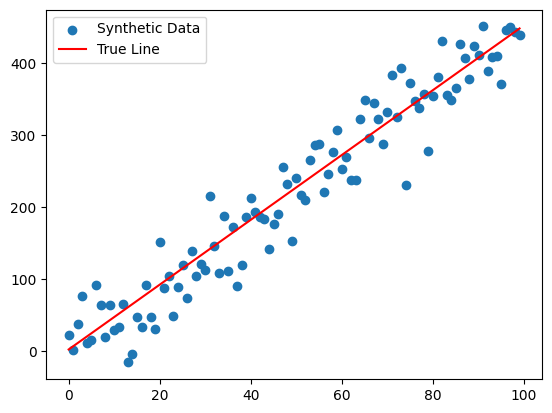

In [5]:
# Scatter plot
import matplotlib.pyplot as plt

plt.scatter(X, y, label="Synthetic Data")
plt.plot(X, 4.5 * X + 2.2, color='red', label="True Line")
plt.legend()
plt.show()

# Linear Regression in Numpy

In [6]:
# make X and y 2D
X = X.reshape(-1, 1)
y = y.reshape(-1, 1)

In [7]:
X.shape, y.shape

((100, 1), (100, 1))

### Split the data into training and testing sets

In [8]:
# Shuffle the data
indices = np.arange(N_SAMPLES)
np.random.shuffle(indices)
X = X[indices]
y = y[indices]

In [9]:
# Split the data
TRAIN_SIZE = 0.8
N_TRAIN = int(TRAIN_SIZE * N_SAMPLES)
X_train, X_test = X[:N_TRAIN], X[N_TRAIN:]
y_train, y_test = y[:N_TRAIN], y[N_TRAIN:]

In [10]:
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 80
Test set size: 20


### Standardize the data

In [11]:
def standardize(data, mean, std):
    return (data - mean) / std

In [12]:
X_mean, X_std = X_train.mean(), X_train.std()
y_mean, y_std = y_train.mean(), y_train.std()

In [13]:
X_train = standardize(X_train, X_mean, X_std)
y_train = standardize(y_train, y_mean, y_std)
X_test = standardize(X_test, X_mean, X_std)
y_test = standardize(y_test, y_mean, y_std)

In [14]:
print(f"X_train mean: {X_train.mean():.2f}, std: {X_train.std():.2f}")
print(f"y_train mean: {y_train.mean():.2f}, std: {y_train.std():.2f}")

X_train mean: -0.00, std: 1.00
y_train mean: 0.00, std: 1.00


# Weights and Bias

In [43]:
# Initialize the weights and bias
INPUT_DIM = X_train.shape[1]
OUTPUT_DIM = 1
W = np.random.randn(INPUT_DIM, OUTPUT_DIM)
b = np.zeros(OUTPUT_DIM)

In [44]:
W.shape, b.shape

((1, 1), (1,))

In [45]:
N_LOOPS = 100
LEARNING_RATE = 0.1

In [46]:
# Training loop
for epoch in range(N_LOOPS):
    # Forward pass
    y_pred = np.dot(X_train, W) + b

    # Compute the mse loss
    error = y_pred - y_train
    loss = np.mean(error ** 2)

    # Compute the gradients
    W_grad = np.dot(X_train.T, error) / N_TRAIN
    b_grad = np.sum(error) / N_TRAIN

    # Update the weights
    W -= LEARNING_RATE * W_grad
    b -= LEARNING_RATE * b_grad

    if epoch % 10 == 0:
        print(f"Epoch: {epoch}, Loss: {loss:.4f}")

Epoch: 0, Loss: 3.8637
Epoch: 10, Loss: 0.5380
Epoch: 20, Loss: 0.1336
Epoch: 30, Loss: 0.0845
Epoch: 40, Loss: 0.0785
Epoch: 50, Loss: 0.0778
Epoch: 60, Loss: 0.0777
Epoch: 70, Loss: 0.0777
Epoch: 80, Loss: 0.0777
Epoch: 90, Loss: 0.0777
